# 15 · Segmenting a microstructure with a tiny U-Net

*A CNN that labels every pixel, not the whole image. The classic microscopy task.*

> ⏱ **Runtime:** ~30 s on a laptop CPU (no GPU) · 🎓 **Level:** intermediate · 📊 **Data:** synthetic two-phase micrographs

### 🎯 What you'll learn
1. what image **segmentation** is, and why grain/phase maps in microscopy need it,
2. why a **CNN (U-Net)** beats plain brightness thresholding when phases differ by **texture**,
3. how to score a segmentation with **Dice / IoU**,
4. how to turn the predicted mask into a materials number, the **phase fraction**.

### 🧭 What you need to know first
- The CNN idea from notebooks **04** and **10** (small filters sliding over an image).
- The **Dice** overlap score from notebook **06**.
- That two phases can look alike in *brightness* yet differ in *texture*.

> 🧭 **Beyond nanoindentation.** Notebooks 04/10 classify a *whole* curve or image. Here the
> job is **per-pixel**: label each point of a micrograph as phase A or phase B. That is
> **segmentation**, and it is how you measure grain size, phase fraction, or porosity from an
> image. We use a **synthetic** microstructure so the correct answer (the mask) is known exactly.

### Step 0: set-up

Run the cell below first: click it and press **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages, about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it runs instantly.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
import torch, torch.nn as nn                    # the neural-network toolkit (CPU is fine here)
from scipy.ndimage import gaussian_filter       # smooths random noise into blobby fields
from sklearn.model_selection import train_test_split
torch.manual_seed(0); rng = np.random.default_rng(0)   # fixed seeds -> repeatable

## 1 · A synthetic two-phase microstructure

We build small grayscale "micrographs" whose two phases share the **same average brightness**
but differ in **texture** (one fine, one coarse). A known **mask** says which pixel is which.

> 🧠 **segmentation**: labelling every *pixel* of an image with a class (here: phase A vs phase B), producing a map the same size as the image.

> 🧠 **mask**: the ground-truth label image: 1 where a pixel is phase B, 0 where phase A.

> ✅ **Look for:** a row of micrographs with their true masks, and a histogram where **both phases sit on top of each other in brightness**, so brightness alone cannot separate them.

dataset: (220, 96, 96)  | phase-B fraction spans 0.42 to 0.58


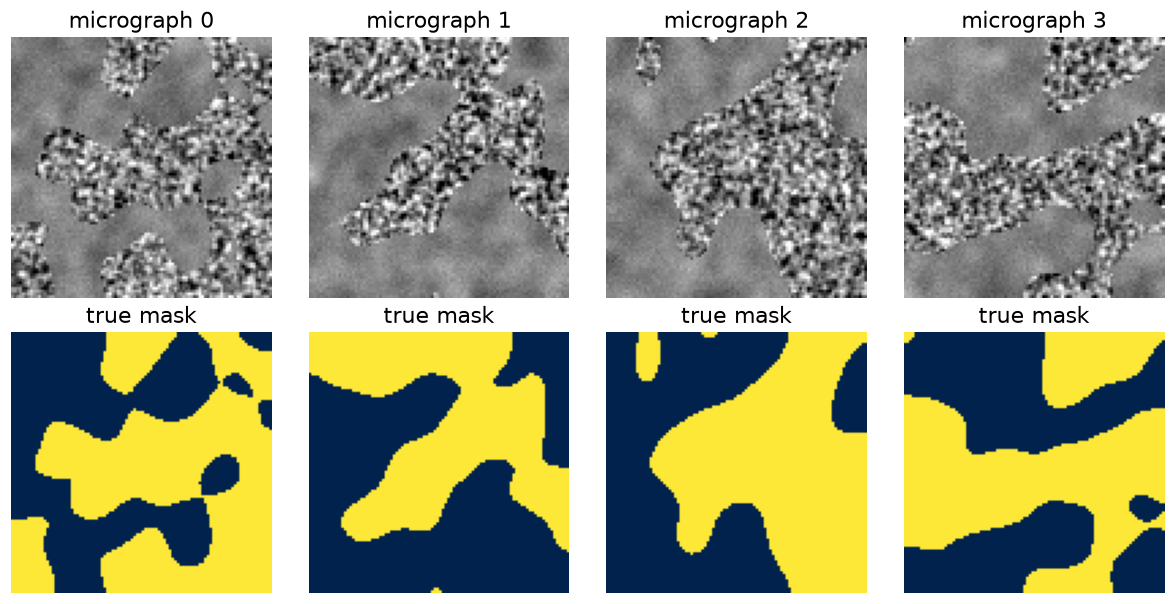

In [3]:
def make_micrograph(rng, size=96):
    # A smooth random field sets the two-phase layout (like a spinodal microstructure).
    field = gaussian_filter(rng.standard_normal((size, size)), sigma=rng.uniform(6, 10))
    mask = (field > np.quantile(field, rng.uniform(0.42, 0.58))).astype(np.float32)  # ~40-60% phase B
    # Same mean brightness for both phases, but different TEXTURE: fine vs coarse grain.
    fine   = gaussian_filter(rng.standard_normal((size, size)), 0.7)
    coarse = gaussian_filter(rng.standard_normal((size, size)), 3.0)
    img = np.where(mask > 0, fine, coarse)                 # phase B = fine, phase A = coarse
    img = 0.5 + 0.16 * (img - img.mean()) / (img.std() + 1e-6)   # centre both phases on 0.5
    img = np.clip(img + 0.03 * rng.standard_normal((size, size)), 0, 1)   # a little sensor noise
    return img.astype(np.float32), mask

N = 220
imgs = np.zeros((N, 96, 96), np.float32); masks = np.zeros((N, 96, 96), np.float32)
for i in range(N):                                        # build the whole synthetic dataset
    imgs[i], masks[i] = make_micrograph(rng)
print("dataset:", imgs.shape, " | phase-B fraction spans",
      f"{masks.mean((1,2)).min():.2f} to {masks.mean((1,2)).max():.2f}")

fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for k in range(4):
    ax[0, k].imshow(imgs[k], cmap="gray"); ax[0, k].set_title(f"micrograph {k}"); ax[0, k].axis("off")
    ax[1, k].imshow(masks[k], cmap="cividis"); ax[1, k].set_title("true mask"); ax[1, k].axis("off")
fig.tight_layout()

*🖼 **Figure.** Top: the synthetic micrographs. Bottom: the phase each pixel belongs to. The two phases differ in the *fineness* of the texture, not their grey level.*

> ✅ **Look for:** the brightness histograms of the two phases almost perfectly overlap, so no single grey-level threshold can tell them apart.

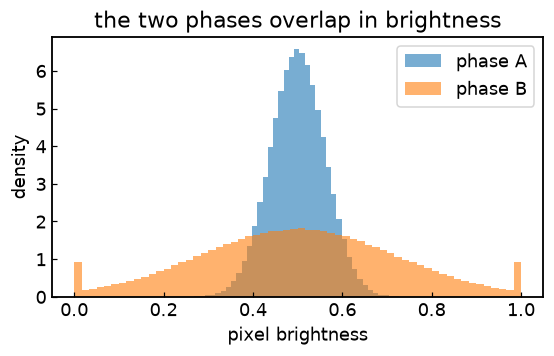

In [4]:
a = imgs[masks == 0]; b = imgs[masks > 0]            # pixel brightnesses of each phase
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.hist(a, bins=60, alpha=.6, label="phase A", density=True)
ax.hist(b, bins=60, alpha=.6, label="phase B", density=True)
ax.set_xlabel("pixel brightness"); ax.set_ylabel("density"); ax.legend()
ax.set_title("the two phases overlap in brightness"); fig.tight_layout()

*🖼 **Figure.** The phases are inseparable by brightness alone. A method that only looks at one pixel is stuck; you need one that looks at the neighbourhood, i.e. texture.*

## 2 · The obvious non-ML approach fails

The classic recipe is **thresholding**: call every pixel brighter than some value phase B. Because
our phases share a brightness, this can only guess.

> ✅ **Look for:** a **Dice score near 0.5** for thresholding, no better than a coin toss on a roughly even split. This is the bar the CNN has to beat.

In [5]:
def dice(pred, truth):                               # overlap score, 1 = perfect, 0 = none
    p, t = pred > 0.5, truth > 0.5
    return 2 * (p & t).sum() / (p.sum() + t.sum() + 1e-9)

thr = []
for i in range(N):
    p = (imgs[i] > np.median(imgs[i])).astype(np.float32)   # threshold each image at its median
    thr.append(max(dice(p, masks[i]), dice(1 - p, masks[i])))  # allow either phase to be the "bright" one
thr_dice = float(np.mean(thr))
print(f"brightness-threshold Dice: {thr_dice:.2f}   (chance-level on a two-phase split)")

brightness-threshold Dice: 0.51   (chance-level on a two-phase split)


*🖼 **Figure.** Thresholding lands around 0.5: it cannot see texture, only brightness. Now we give a small CNN the spatial context it needs.*

## 3 · A tiny U-Net

A **U-Net** is the standard segmentation network: an **encoder** shrinks the image while learning
*what* is there, a **decoder** grows it back to full size to say *where*, and **skip connections**
hand fine detail from the encoder straight across so edges stay crisp.

```
   image ──▶ enc1 ──▶ enc2 ──▶ bottleneck ──▶ dec2 ──▶ dec1 ──▶ mask
              │         │                       ▲        ▲
              └──────── skip ───────────────────┘        │
                        └──── skip ─────────────────────-┘
```

> 🧠 **U-Net**: an encoder-decoder CNN with skip connections that outputs a full-size label map. The workhorse of microscopy segmentation.

> 🧠 **skip connection**: a shortcut that copies an encoder feature map to the matching decoder stage, so fine spatial detail is not lost in the squeeze.

> ✅ **Look for:** the training loss falling over ~18 passes. On a laptop CPU this takes well under a minute (the images and the network are deliberately small).

parameters: 65773  final loss: 0.054


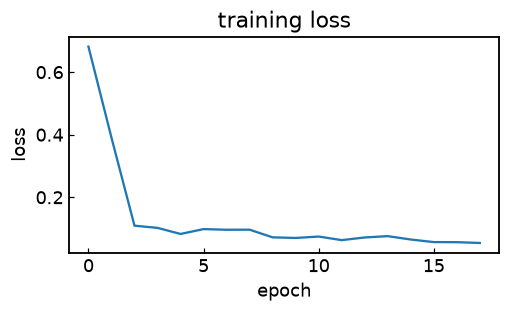

In [6]:
X = torch.tensor(imgs)[:, None]; Yt = torch.tensor(masks)[:, None]   # add a channel axis -> (N,1,96,96)
Xtr, Xte, Ytr, Yte = train_test_split(X, Yt, test_size=0.25, random_state=0)

def block(i, o):                                     # two 3x3 convolutions + ReLU
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.ReLU(),
                         nn.Conv2d(o, o, 3, padding=1), nn.ReLU())

class TinyUNet(nn.Module):
    def __init__(self, c=12):
        super().__init__()
        self.enc1 = block(1, c); self.enc2 = block(c, 2 * c); self.bott = block(2 * c, 4 * c)
        self.pool = nn.MaxPool2d(2)                                   # halves the size
        self.up2 = nn.ConvTranspose2d(4 * c, 2 * c, 2, 2); self.dec2 = block(4 * c, 2 * c)  # doubles it back
        self.up1 = nn.ConvTranspose2d(2 * c, c, 2, 2);     self.dec1 = block(2 * c, c)
        self.head = nn.Conv2d(c, 1, 1)               # 1x1 conv -> one score per pixel
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); b = self.bott(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], 1))   # skip: glue encoder features back on
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.head(d1)                          # logits, same H×W as the input

net = TinyUNet(); opt = torch.optim.Adam(net.parameters(), 2e-3)
lossf = nn.BCEWithLogitsLoss()                       # per-pixel binary loss
losses = []
for epoch in range(18):
    perm = torch.randperm(len(Xtr))                  # shuffle each epoch
    for i in range(0, len(Xtr), 16):                 # mini-batches of 16 images
        idx = perm[i:i + 16]
        opt.zero_grad(); loss = lossf(net(Xtr[idx]), Ytr[idx]); loss.backward(); opt.step()
    losses.append(loss.item())
print("parameters:", sum(p.numel() for p in net.parameters()), " final loss:", round(losses[-1], 3))

fig, ax = plt.subplots(figsize=(4.8, 3)); ax.plot(losses)
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("training loss"); fig.tight_layout()

*🖼 **Figure.** A ~45k-parameter U-Net. The loss drops quickly because the texture cue is strong once the network can look at a patch instead of a single pixel.*

## 4 · Does it work, and can we measure the material?

We score on **held-out** micrographs the network never saw, compare masks by eye, and then do the
thing a materials scientist actually wants: read off the **phase fraction**.

> 🧠 **IoU (intersection over union)**: another overlap score: shared area divided by combined area. Stricter cousin of Dice; both are 1 when perfect.

> 🧠 **phase fraction**: the share of the area that is a given phase, here just the fraction of mask pixels equal to phase B. A standard microstructure metric.

> ✅ **Look for:** a **CNN Dice well above 0.85** (far past thresholding's ~0.5), tidy predicted masks, and predicted phase fractions that track the truth along the diagonal.

CNN  Dice 0.98  IoU 0.95   vs   threshold Dice 0.51


phase-fraction mean abs error: 0.008


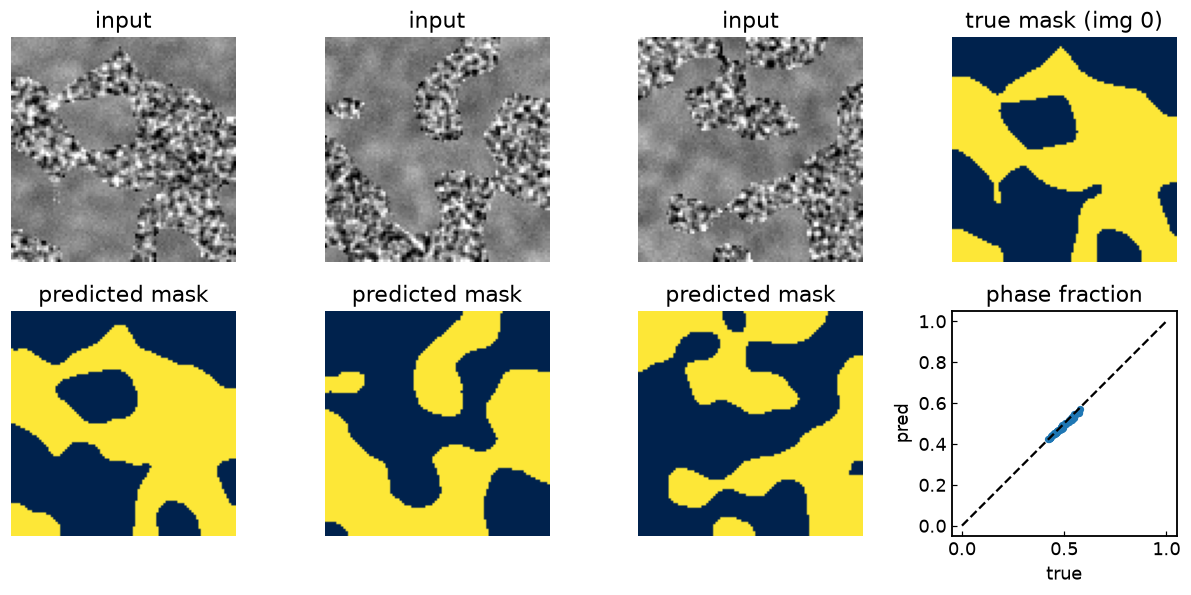

In [7]:
net.eval()
with torch.no_grad():
    prob = torch.sigmoid(net(Xte))                   # per-pixel probability of phase B
    pred = (prob > 0.5).float()                      # hard mask

def iou(p, t):
    p, t = p > 0.5, t > 0.5
    return (p & t).sum() / ((p | t).sum() + 1e-9)

cnn_dice = float(np.mean([dice(pred[i, 0].numpy(), Yte[i, 0].numpy()) for i in range(len(Xte))]))
cnn_iou  = float(np.mean([iou(pred[i, 0].numpy(),  Yte[i, 0].numpy()) for i in range(len(Xte))]))
print(f"CNN  Dice {cnn_dice:.2f}  IoU {cnn_iou:.2f}   vs   threshold Dice {thr_dice:.2f}")

pf_true = Yte[:, 0].mean((1, 2)).numpy()             # true phase-B fraction per test image
pf_pred = pred[:, 0].mean((1, 2)).numpy()            # predicted phase-B fraction
print("phase-fraction mean abs error:", round(float(np.abs(pf_true - pf_pred).mean()), 3))

fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for k in range(3):
    ax[0, k].imshow(Xte[k, 0], cmap="gray"); ax[0, k].set_title("input"); ax[0, k].axis("off")
    ax[1, k].imshow(pred[k, 0], cmap="cividis"); ax[1, k].set_title("predicted mask"); ax[1, k].axis("off")
ax[0, 3].imshow(Yte[0, 0], cmap="cividis"); ax[0, 3].set_title("true mask (img 0)"); ax[0, 3].axis("off")
ax[1, 3].scatter(pf_true, pf_pred, s=14); ax[1, 3].plot([0, 1], [0, 1], "k--")
ax[1, 3].set_xlabel("true"); ax[1, 3].set_ylabel("pred"); ax[1, 3].set_title("phase fraction"); ax[1, 3].set_aspect("equal")
fig.tight_layout()

*🖼 **Figure.** The U-Net recovers the phases from texture alone, and its phase-fraction estimates fall on the diagonal, so the segmentation is quantitatively usable.*

### ✅ Self-check
A fast sanity check on the results above. If a later edit knocks a number out of range, the cell below stops with an `AssertionError`, which is a useful heads-up rather than a bug.

In [8]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert cnn_dice > 0.85, "the U-Net should segment the two phases well"
assert cnn_dice > thr_dice + 0.25, "the CNN should clearly beat brightness thresholding"
assert float(np.abs(pf_true - pf_pred).mean()) < 0.06, "predicted phase fraction should track the truth"
print("self-check passed ✓ — the U-Net segments texture-defined phases")

self-check passed ✓ — the U-Net segments texture-defined phases


## ✅ Recap
- **Segmentation** labels every pixel, turning a micrograph into a phase or grain map you can measure.
- When phases differ by **texture**, brightness thresholding is stuck near chance while a small **U-Net** reaches Dice > 0.9, because convolutions read the neighbourhood.
- A predicted mask gives materials numbers directly: the **phase fraction** here matches the truth to a few percent.

## 🔧 Try it yourself
A few small experiments (re-run the cell after each):
1. Raise the sensor noise in `make_micrograph` (0.03 -> 0.10). Does Dice fall? By how much?
2. Make the textures more alike (change the coarse `sigma` from 3.0 toward 1.0). When does the U-Net start to struggle?
3. Print the IoU per image and show the **worst** prediction. What does the network get wrong, and where?

## 🩹 Common errors & fixes
- **Shapes must be divisible by 4** for the two poolings; 96 works, an odd size will crash the concat.
- **`RuntimeError: expected input... channels`** means the channel axis is missing; keep the `[:, None]`.
- **Dice looks stuck at ~0.5** on your own data usually means the phases really are separable by brightness, in which case a threshold is fine and you do not need the CNN.

---
**Next:** Try it on a **real** micrograph of your own (same idea: image in, mask out), or see **`06_correlative_registration.ipynb`** for another use of the Dice score.